# Laptop Price Prediction

In [117]:
import numpy as np
import pandas as pd

# Data Preperation

In [118]:
df = pd.read_csv("datasets/laptop_price.csv", encoding='latin1')

In [119]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [120]:
# cleaning the columns
df.columns = df.columns.str.lower().str.replace(" " , "_")

In [121]:
# Select only the columns that are text strings
strings = list(df.dtypes[df.dtypes == "str"].index)
strings

['company',
 'product',
 'typename',
 'screenresolution',
 'cpu',
 'ram',
 'memory',
 'gpu',
 'opsys',
 'weight']

In [122]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [123]:
df.head(3)

,laptop_id,company,product,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,price_euros
0,1,apple,macbook_pro,ultrabook,13.3,ips_panel_retina_display_2560x1600,intel_core_i5_2.3ghz,8gb,128gb_ssd,intel_iris_plus_graphics_640,macos,1.37kg,1339.69
1,2,apple,macbook_air,ultrabook,13.3,1440x900,intel_core_i5_1.8ghz,8gb,128gb_flash_storage,intel_hd_graphics_6000,macos,1.34kg,898.94
2,3,hp,250_g6,notebook,15.6,full_hd_1920x1080,intel_core_i5_7200u_2.5ghz,8gb,256gb_ssd,intel_hd_graphics_620,no_os,1.86kg,575.00


In [124]:
del df["laptop_id"]  # deleted the unnecessary column

In [125]:
df["ram"] = df["ram"].str.replace("gb","").astype(int)

In [126]:
df["weight"] = df["weight"].str.replace("kg","").astype(float)

# Exploratory Data Analysis

In [127]:
for col in df.columns:
    print(col)                           # printing col name
    print(df[col].unique()[:5])          # printing 5 unique values from the column
    print(df[col].nunique())             # printing how many total unique values are there in the column
    print()                              # used for spacing

company
<StringArray>
['apple', 'hp', 'acer', 'asus', 'dell']
Length: 5, dtype: str
19

product
<StringArray>
['macbook_pro', 'macbook_air', '250_g6', 'aspire_3', 'zenbook_ux430un']
Length: 5, dtype: str
576

typename
<StringArray>
['ultrabook', 'notebook', 'netbook', 'gaming', '2_in_1_convertible']
Length: 5, dtype: str
6

inches
[13.3 15.6 15.4 14.  12. ]
18

screenresolution
<StringArray>
['ips_panel_retina_display_2560x1600',                           '1440x900',
                  'full_hd_1920x1080', 'ips_panel_retina_display_2880x1800',
                           '1366x768']
Length: 5, dtype: str
40

cpu
<StringArray>
[      'intel_core_i5_2.3ghz',       'intel_core_i5_1.8ghz',
 'intel_core_i5_7200u_2.5ghz',       'intel_core_i7_2.7ghz',
       'intel_core_i5_3.1ghz']
Length: 5, dtype: str
116

ram
[ 8 16  4  2 12]
9

memory
<StringArray>
['128gb_ssd', '128gb_flash_storage', '256gb_ssd', '512gb_ssd', '500gb_hdd']
Length: 5, dtype: str
39

gpu
<StringArray>
['intel_iris_plus_graph

## Distribution of Price

<Axes: xlabel='price_euros', ylabel='Count'>

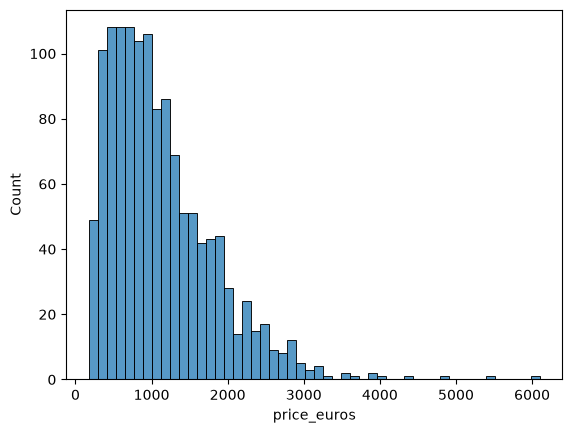

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df.price_euros , bins = 50)

In [129]:
# as we have longtail graph
price_logs = np.log1p(df.price_euros)
price_logs

0       7.200940
1       6.802328
2       6.356108
3       7.839309
4       7.498094
          ...   
1298    6.459904
1299    7.313220
1300    5.438079
1301    6.639876
1302    5.913503
Name: price_euros, Length: 1303, dtype: float64

<Axes: xlabel='price_euros', ylabel='Count'>

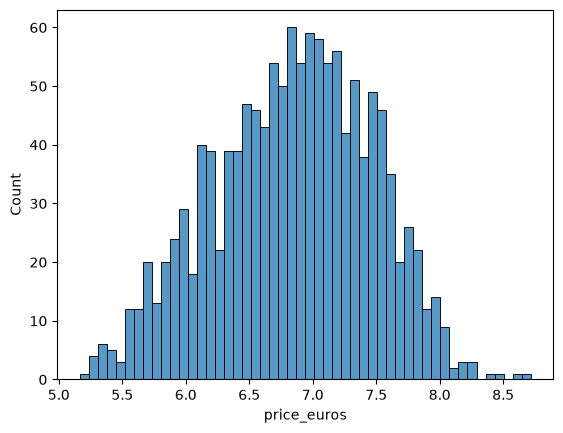

In [130]:
sns.histplot(price_logs , bins = 50)

## Missing Values

In [131]:
df.isnull().sum()   # here no missing values found

company             0
product             0
typename            0
inches              0
screenresolution    0
cpu                 0
ram                 0
memory              0
gpu                 0
opsys               0
weight              0
price_euros         0
dtype: int64

# Setting Up the validation framework

In [132]:
n = len(df)
n_val = int(n * 0.2)
n_test = int( n * 0.2)
n_train = n - n_val - n_test

n_train, n_val, n_test

(783, 260, 260)

In [133]:
# so here our data is perfet so we move frward as we are not missing any values
n_train + n_val + n_test

1303

In [134]:
idx = np.arange(n)  # Create a list of all row numbers

In [135]:
# shuffeling the index list randomly
np.random.seed(2)
np.random.shuffle(idx)

In [136]:
# Splitting the Actual Dataframe using shuffled index

df_train = df.iloc[idx[ : n_train]]
df_val = df.iloc[idx[ n_train : n_train + n_val]]
df_test = df.iloc[idx[ n_train + n_val : ]]

In [137]:
# Reset the index row labels to start fresh from 0

df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_val.reset_index(drop = True)

In [138]:
# Converting the target variable (MSRP) into log scale for better model performance
y_train = np.log1p(df_train.price_euros.values)
y_val = np.log1p(df_val.price_euros.values)
y_test = np.log1p(df_test.price_euros.values)

In [143]:
# Remove the target column (MSRP) from the feature DataFrames (so we dont accidently use it for training purpose)
del df_train["price_euros"]
del df_val["price_euros"]
del df_test["price_euros"]

## Linear Regression

In [145]:
df_train.iloc[10]

company                                          toshiba
product                                    satellite_pro
typename                                        notebook
inches                                              14.0
screenresolution                                1366x768
cpu                 intel_pentium_dual_core_4405u_2.1ghz
ram                                                    4
memory                                         128gb_ssd
gpu                                intel_hd_graphics_510
opsys                                         windows_10
weight                                              1.75
Name: 10, dtype: object

In [151]:
xi = [14, 4, 1.75]  # The characteristics from our features (e.g., inches, ram, weight)
w0 = 7.17 # Bias (Intercept)
w = [0.01, 0.04, 0.002]        # Weights assigned to inches, ram, and weight respectively

In [152]:
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred =pred + w[j]*xi[j]
    return pred

In [153]:
log_prediction = linear_regression(xi)
print(f"Predicted Log Price: {log_prediction}")

Predicted Log Price: 7.4735


In [154]:
real_price = np.expm1(log_prediction)
print(f"Predicted Price in Euros: {real_price:.2f}")

Predicted Price in Euros: 1759.76


# Linear Regression Vector Form

In [ ]:
# Combine our weights into a single array containing the bias
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [ ]:
# Build mock feature vectors for 3 laptops (adding 1 as the first element for the bias)
# Format: [1, inches, ram, weight]
x1  = [1, 13.3, 8, 1.37]
x2  = [1, 15.6, 4, 1.86]
x3  = [1, 15.4, 16, 1.83]

X = np.array([x1, x2, x3])  # Stack them up into a mini feature matrix X


In [161]:
def linear_regression_vector(X):
    return X.dot(w_new)

In [164]:
log_predictions = linear_regression_vector(X)
print("Log Predictions:", log_predictions)
print("Real Price Predictions (Euros):", np.expm1(log_predictions))


Log Predictions: [7.62574 7.48972 7.96766]
Real Price Predictions (Euros): [2049.29712366 1788.55094742 2885.09599188]


## Training A linear Regression Model

In [172]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0] , w_full[1 :]

# Laptop Price Baseline Model

In [173]:
base = ["inches", "ram", "weight"]  # Define our initial numeric base features
X_train = df_train[base].values     # Extract the values into our feature matrix X_train

# Pass X_train and our y_train target into our training function!
w0 , w = train_linear_regression(X_train,y_train)

y_pred = w0 + X_train.dot(w)   #predictions on the training data

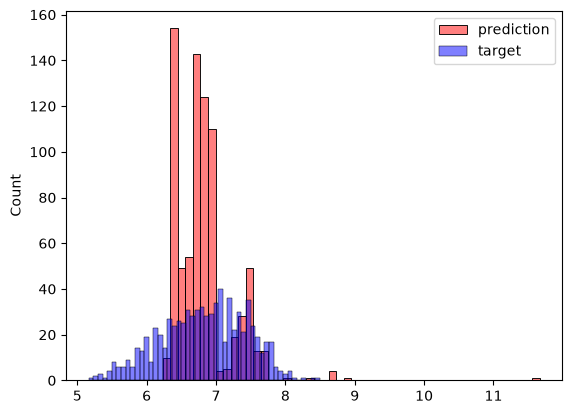

In [176]:
# plotting the predicted data

sns.histplot(y_pred, color="red", alpha=0.5, bins=50, label='prediction')
sns.histplot(y_train, color='blue', alpha=0.5, bins=50, label='target')
plt.legend()

# Root Mean Squared Error

In [177]:
def rmse(y, y_pred):
    error = y - y_pred
    squared_error = error ** 2
    mean_squared_error = squared_error.mean()
    return np.sqrt(mean_squared_error)

In [178]:
rmse(y_train, y_pred)

np.float64(0.4449359443805839)

# Validating the Model

In [182]:
def prepare_X(df):
    df_num = df[base]
    X = df_num.values
    return X

In [183]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4703790517007284)

# Categorical Value

In [186]:
df_train['typename'].value_counts()

typename
notebook              437
gaming                122
ultrabook             122
2_in_1_convertible     73
workstation            22
netbook                 7
Name: count, dtype: int64

In [187]:
companies = list(df.company.value_counts().head(5).index)
print("Top companies:", companies)

Top companies: ['dell', 'lenovo', 'hp', 'asus', 'acer']


In [188]:
types = list(df.typename.value_counts().index)
print("Laptop types:", types)

Laptop types: ['notebook', 'gaming', 'ultrabook', '2_in_1_convertible', 'workstation', 'netbook']


In [189]:
def prepare_X(df):
    df = df.copy()
    features = base.copy() # base = ["inches", "ram", "weight"]

    # 1. Map out and encode the dynamic laptop types
    for v in types:
        df[f"type_{v}"] = (df.typename == v).astype(int)
        features.append(f"type_{v}")
        
    # 2. Map out and encode the top 5 laptop companies exactly like the car blueprint
    for v in companies:
        df[f"company_{v}"] = (df.company == v).astype(int)
        features.append(f"company_{v}")

    # 3. Filter the target features, fill missing indices, and return the numerical array matrix
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [190]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(714.0749882643239)

#  Regularisation

In [195]:
def train_linear_regression_reg(X, y, r=0.001):
    # 1. Create a column of ones for the bias
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # 2. Calculate the standard Gram Matrix
    XTX = X.T.dot(X)
    
    # 3. Inject the regularization penalty 'r' along the diagonal matrix path
    XTX = XTX + r * np.eye(XTX.shape[0])

    # 4. Compute the linear algebra inverse and extract weights
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [198]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4177897060093674)

# Tuning The Model

In [199]:
# Evaluate a sweep of potential r values to find the sweet spot
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(f"r: {r:<7} | w0: {w0:<18} | score: {score}")

r: 0.0     | w0: -7292.158588850787 | score: 714.0749882643239
r: 1e-05   | w0: 5.552924939698317  | score: 0.4177344269484113
r: 0.0001  | w0: 5.552752637154229  | score: 0.4177349059576207
r: 0.001   | w0: 5.551027491849827  | score: 0.4177397319628341
r: 0.1     | w0: 5.367808448492464  | score: 0.4184483034924583
r: 1       | w0: 4.140479161916363  | score: 0.4329546951087385
r: 10      | w0: 1.351664386392573  | score: 0.5192022340088125


# Using the Model

In [200]:
# 1. Combine training and validation data sets together
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

# 2. Extract and stack the full target arrays
y_full_train = np.concatenate([y_train, y_val])

# 3. Process the full matrix and train using your optimal r parameter (e.g., 0.001)
X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# 4. Run the ultimate final test evaluation on the unseen test dataset!
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

final_score = rmse(y_test, y_pred)
print("Final Test RMSE Score:", final_score)

Final Test RMSE Score: 0.4076432013214434


# Final Plotting

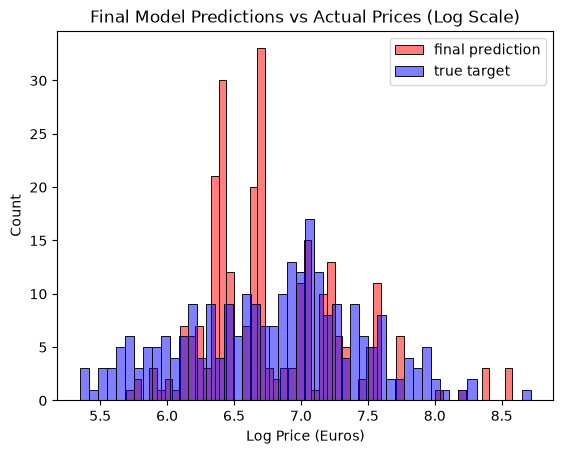

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot both the final test predictions and true test targets to see the match
sns.histplot(y_pred, color="red", alpha=0.5, bins=50, label='final prediction')
sns.histplot(y_test, color='blue', alpha=0.5, bins=50, label='true target')

plt.title('Final Model Predictions vs Actual Prices (Log Scale)')
plt.xlabel('Log Price (Euros)')
plt.ylabel('Count')
plt.legend()
plt.show()